In [1]:
import pandas as pd
import glob
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
dataframes = []
paths = glob.glob('/Users/connorhall/datasets/inst414/module 4 assignment/*.csv')
for csv in paths:
    df = pd.read_csv(csv, usecols=['STATE', 'EVENT_TYPE'])
    dataframes.append(df)
    
combined_df = pd.concat(dataframes, axis=0, ignore_index=True)
combined_df


,STATE,EVENT_TYPE
0,TENNESSEE,Tornado
1,TENNESSEE,Tornado
2,TENNESSEE,Thunderstorm Wind
3,TENNESSEE,Tornado
4,TENNESSEE,Thunderstorm Wind
...,...,...
653796,ILLINOIS,Tornado
653797,ILLINOIS,Tornado
653798,ILLINOIS,Tornado
653799,ILLINOIS,Tornado


## validate input

In [3]:
# state must contain only characters and whitespaces
print(len(combined_df[combined_df['STATE'].str.contains('[^\\w\\s]')]))
# event must be string
print(len(combined_df[combined_df['EVENT_TYPE'].str.contains('\\d')]))
# no null values
print(len(combined_df) - len(combined_df.dropna()))

0
0
0


In [4]:
# verify that counts are reasonable
print(combined_df['STATE'].value_counts()[:10],'\n')
print(combined_df['EVENT_TYPE'].value_counts()[:10])

STATE
TEXAS           48031
KANSAS          23068
CALIFORNIA      22551
VIRGINIA        21898
OKLAHOMA        21839
SOUTH DAKOTA    21079
MISSOURI        20475
NEW YORK        20381
ILLINOIS        20278
IOWA            19781
Name: count, dtype: int64 

EVENT_TYPE
Thunderstorm Wind           180798
Hail                         87696
Flash Flood                  40852
High Wind                    38968
Winter Weather               36570
Drought                      32686
Flood                        28223
Winter Storm                 27536
Marine Thunderstorm Wind     23964
Heavy Snow                   21298
Name: count, dtype: int64


## calculate # of weather events per state

In [5]:
# count number of events per state
event_count = pd.crosstab(combined_df['STATE'], combined_df['EVENT_TYPE']).stack('EVENT_TYPE')
# get lists of states and events
states = event_count.index.get_level_values('STATE').tolist()
events = event_count.index.get_level_values('EVENT_TYPE').tolist()

events_df = pd.DataFrame({'State': states, 'Event': events})
# get list of # of events
events_df['Count'] = event_count.values
events_df

,State,Event,Count
0,ALABAMA,Astronomical Low Tide,1
1,ALABAMA,Avalanche,0
2,ALABAMA,Blizzard,0
3,ALABAMA,Coastal Flood,28
4,ALABAMA,Cold/Wind Chill,132
...,...,...,...
3721,WYOMING,Volcanic Ashfall,0
3722,WYOMING,Waterspout,0
3723,WYOMING,Wildfire,78
3724,WYOMING,Winter Storm,1961


## create weather event count list for each state/location

In [6]:
unique_events = events_df['Event'].unique().tolist()
unique_states = events_df['State'].unique().tolist()

counts = []
for st in unique_states:
    st_filter = events_df[events_df['State'] == st]
    counts.append(st_filter['Count'].tolist())

In [7]:
# add count lists to dataframe
state_events = pd.DataFrame(counts, columns=unique_events, index=unique_states)
pd.options.display.max_columns = None
state_events

,Astronomical Low Tide,Avalanche,Blizzard,Coastal Flood,Cold/Wind Chill,Debris Flow,Dense Fog,Dense Smoke,Drought,Dust Devil,Dust Storm,Excessive Heat,Extreme Cold/Wind Chill,Flash Flood,Flood,Freezing Fog,Frost/Freeze,Funnel Cloud,Hail,Heat,Heavy Rain,Heavy Snow,High Surf,High Wind,Hurricane (Typhoon),Ice Storm,Lake-Effect Snow,Lakeshore Flood,Lightning,Marine Dense Fog,Marine Hail,Marine High Wind,Marine Hurricane/Typhoon,Marine Lightning,Marine Strong Wind,Marine Thunderstorm Wind,Marine Tropical Depression,Marine Tropical Storm,Rip Current,Seiche,Sleet,Sneakerwave,Storm Surge/Tide,Strong Wind,Thunderstorm Wind,Tornado,Tropical Depression,Tropical Storm,Tsunami,Volcanic Ashfall,Waterspout,Wildfire,Winter Storm,Winter Weather
ALABAMA,1,0,0,28,132,0,0,0,857,1,0,202,19,944,242,13,380,18,1237,408,61,75,1,36,7,9,0,0,86,0,0,0,0,0,0,0,0,0,24,0,6,0,32,198,7391,861,18,138,0,0,0,0,98,168
ALASKA,2,21,468,58,24,16,0,0,0,0,0,0,18,2,175,0,23,1,5,0,3,414,11,647,0,17,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,3,5,7,1,0,0,2,2,0,22,350,165
AMERICAN SAMOA,0,0,0,4,0,0,0,0,1,0,0,1,0,83,10,0,0,1,0,3,60,0,34,27,2,0,0,0,4,0,0,0,0,0,0,0,0,0,4,0,0,0,1,26,10,0,0,1,6,0,0,0,0,0
ARIZONA,0,7,0,0,32,18,47,0,384,14,431,1808,5,2002,178,1,4,56,351,725,190,373,0,432,0,1,0,0,67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,50,1508,58,0,0,0,0,0,184,72,25
ARKANSAS,0,0,0,0,64,0,0,0,388,0,5,587,12,1301,966,1,0,31,2011,1203,228,155,0,24,0,83,0,0,38,0,0,0,0,0,0,0,0,0,0,0,3,0,0,52,3415,445,3,39,0,0,0,6,484,850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGINIA,6,3,19,241,177,23,762,0,88,0,0,145,39,1857,2232,0,509,33,1193,303,1497,244,0,529,0,83,0,0,138,0,0,0,0,0,0,0,0,0,6,0,0,0,0,159,8429,175,0,90,0,0,0,6,1139,1773
WASHINGTON,3,14,11,24,23,70,1,26,0,1,39,77,3,60,209,3,50,29,55,131,39,1580,8,481,0,79,0,0,9,0,0,0,0,0,0,0,0,0,4,0,0,0,0,98,163,22,0,0,1,0,0,232,133,192
WEST VIRGINIA,2,0,17,0,158,13,255,0,306,0,0,18,48,936,1067,0,132,7,702,72,81,519,0,294,0,55,0,0,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,562,3444,42,0,0,0,0,0,2,567,1813
WISCONSIN,0,0,36,0,303,1,12,0,359,0,1,187,259,357,725,0,10,43,2376,133,187,701,3,134,0,53,20,46,68,0,0,0,0,0,0,0,0,0,16,4,0,0,0,170,3309,330,0,0,0,0,0,10,1252,1878


## validate output

In [8]:
# verify that output event counts same as input event counts- compare to state_events dataframe
state_selection = 'ALASKA'
# search original dataframe
combined_df[combined_df['STATE'] == state_selection]['EVENT_TYPE'].value_counts().sort_index()

EVENT_TYPE
Astronomical Low Tide        2
Avalanche                   21
Blizzard                   468
Coastal Flood               58
Cold/Wind Chill             24
Debris Flow                 16
Extreme Cold/Wind Chill     18
Flash Flood                  2
Flood                      175
Frost/Freeze                23
Funnel Cloud                 1
Hail                         5
Heavy Rain                   3
Heavy Snow                 414
High Surf                   11
High Wind                  647
Ice Storm                   17
Lightning                    1
Storm Surge/Tide             3
Strong Wind                  5
Thunderstorm Wind            7
Tornado                      1
Tsunami                      2
Volcanic Ashfall             2
Wildfire                    22
Winter Storm               350
Winter Weather             165
Name: count, dtype: int64

## identify ideal k value

In [27]:
intertia_values = []
for k in range(2, 15):
    cluster_model = KMeans(n_clusters=k)
    cluster_model.fit(state_events)
    intertia_values.append(cluster_model.inertia_)

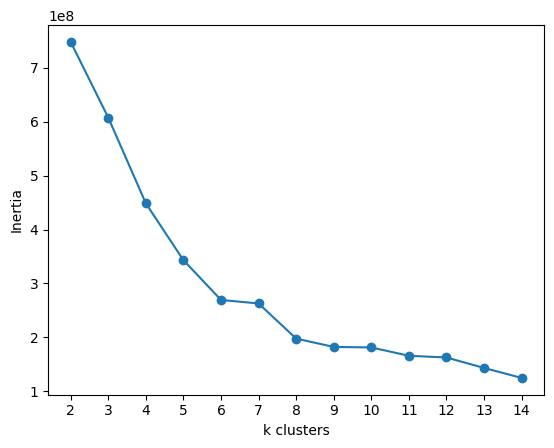

In [28]:
plt.plot(range(2, 15), intertia_values, marker='o')
plt.xticks(range(2, 15))
plt.xlabel('k clusters')
plt.ylabel('Inertia')
plt.show()

## create clusters

In [ ]:
cluster_model = KMeans(n_clusters=7)
state_events['cluster'] = cluster_model.fit_predict(state_events)
state_events['cluster'].value_counts()

cluster
0    31
2    10
6    10
5     8
1     4
3     3
4     3
Name: count, dtype: int64


## sample states in each cluster

In [137]:
# larger clusters
larger_clusters = state_events[['cluster']].groupby('cluster').filter(lambda c: len(c) >= 5)
larger_clusters[['cluster']].groupby('cluster').sample(5)

,cluster
LAKE HURON,0
MASSACHUSETTS,0
CONNECTICUT,0
E PACIFIC,0
HAWAII WATERS,0
NORTH CAROLINA,2
KENTUCKY,2
ALABAMA,2
OHIO,2
PENNSYLVANIA,2


In [132]:
# remaining clusters
smaller_clusters = state_events[['cluster']].groupby('cluster').filter(lambda c: len(c) < 5)
smaller_clusters[['cluster']].sort_values(by='cluster')

,cluster
CALIFORNIA,1
MONTANA,1
NEW MEXICO,1
WYOMING,1
ATLANTIC NORTH,3
ATLANTIC SOUTH,3
GULF OF MEXICO,3
KANSAS,4
OKLAHOMA,4
TEXAS,4


## weather events per cluster

In [133]:
# select top 5 events from each state, then select events shared by at least 3 states
for c in range(0,7):
    # get states in current cluster
    cluster_states = state_events[state_events['cluster'] == c].index.tolist()
    all_events = []
    for s in cluster_states:
        # sort current state's events by count
        events_sorted = events_df[events_df['State'] == s][['Event', 'Count']].sort_values(by='Count', ascending=False)
        # add top 5 events to current cluster event list
        for item in events_sorted[:5]['Event'].values.tolist():
            all_events.append(item)
       
    shared_event_count = pd.DataFrame(all_events).value_counts().to_frame()
    shared_event_count = shared_event_count.rename_axis('Event')
    # select events with shared by >= 3 states
    print(f'cluster {c}: \n {shared_event_count[shared_event_count['count'] >= 3]} \n')

cluster 0: 
                           count
Event                          
Flash Flood                  13
Thunderstorm Wind            13
High Wind                    11
Heavy Snow                   10
Winter Weather                9
Waterspout                    9
Marine Thunderstorm Wind      9
Marine Hail                   8
Flood                         7
Astronomical Low Tide         7
Strong Wind                   6
Marine High Wind              6
Sleet                         6
Winter Storm                  5
Marine Strong Wind            5
Excessive Heat                4
Coastal Flood                 4
Marine Dense Fog              4
Heavy Rain                    3
Drought                       3 

cluster 1: 
                    count
Event                   
High Wind              4
Heavy Snow             3
Thunderstorm Wind      3
Hail                   3 

cluster 2: 
                    count
Event                   
Thunderstorm Wind     10
Flash Flood            9
Hai